# Bank Marketing Dataset Analysis
## Exploratory Data Analysis and Feature Investigation


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')  # or 'classic', 'dark_background', etc.
sns.set_palette('husl')


In [2]:
# Read the dataset
df = pd.read_csv('../dataset/archive/bank-full.csv', sep=';')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Basic dataset information
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df['y'].value_counts(normalize=True))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing Values:
age          0
job          0
marital      0
education    0
default 

Numerical Features Summary:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  

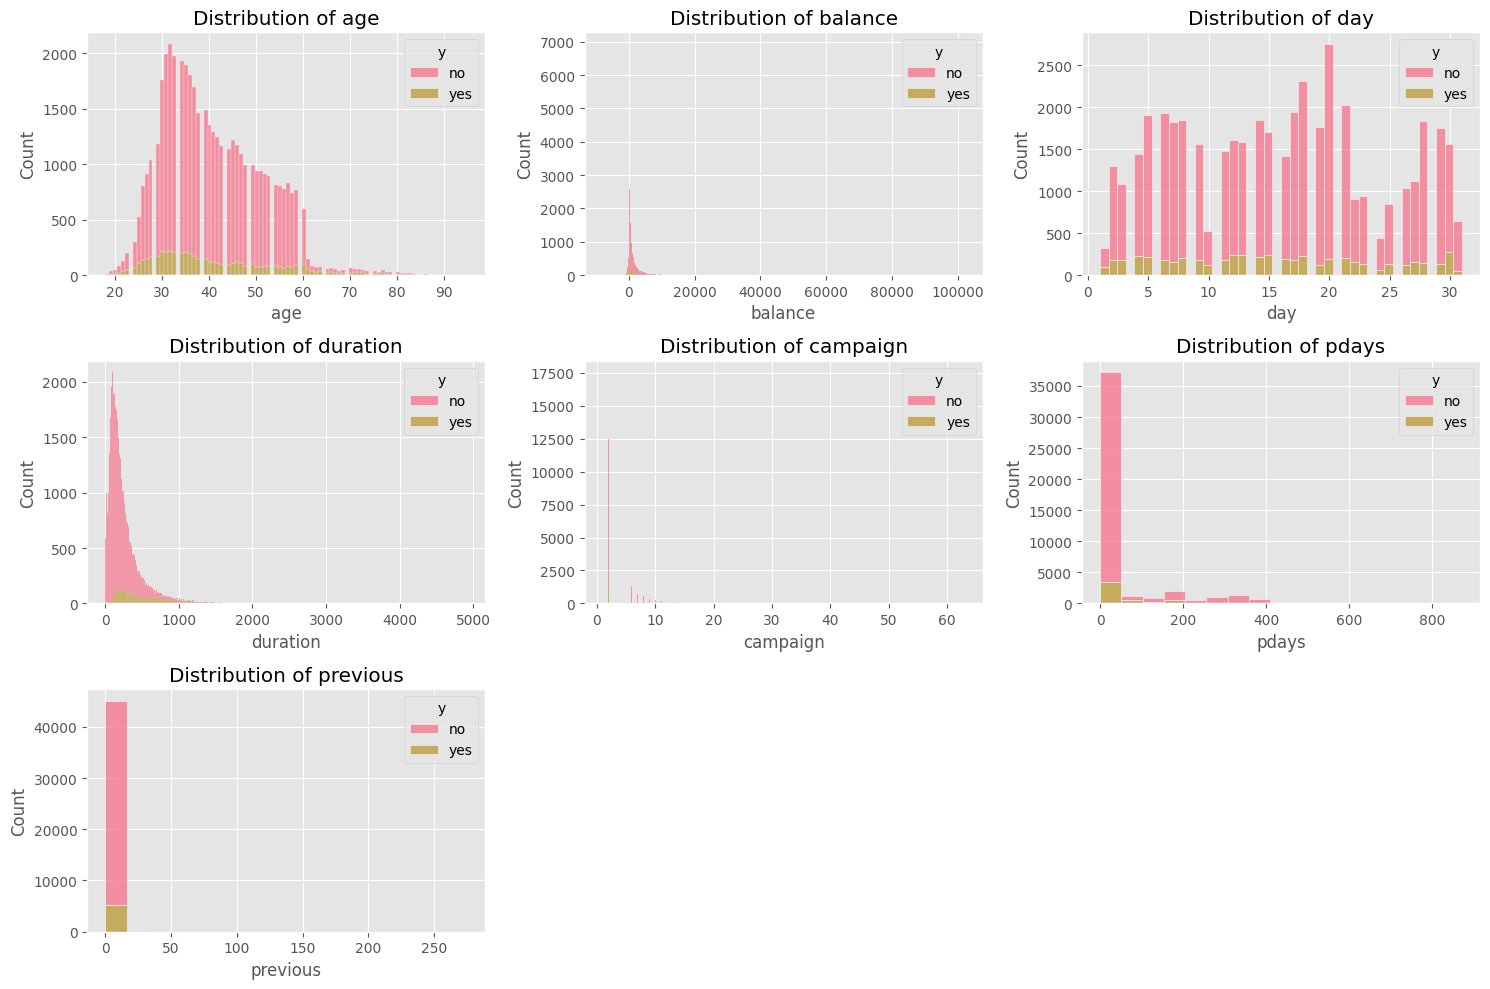

In [4]:
# Numerical features analysis
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

print("Numerical Features Summary:")
print(df[numerical_features].describe())

# Visualize numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=feature, hue='y', multiple="stack")
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


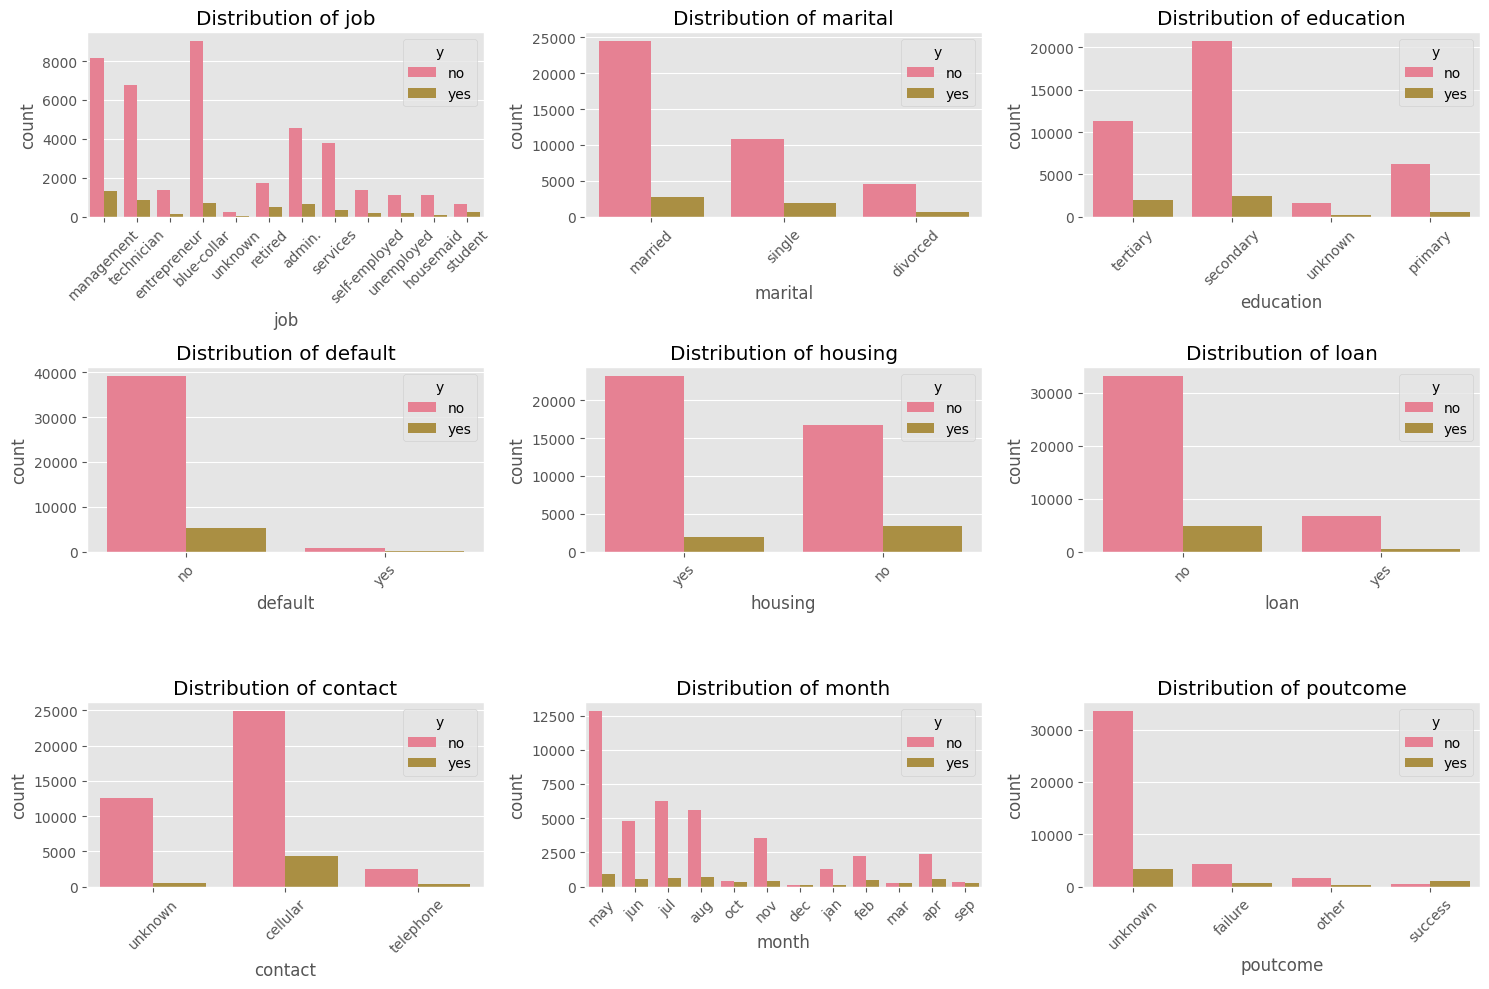

In [5]:
# Categorical features analysis
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Plot categorical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=feature, hue='y')
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


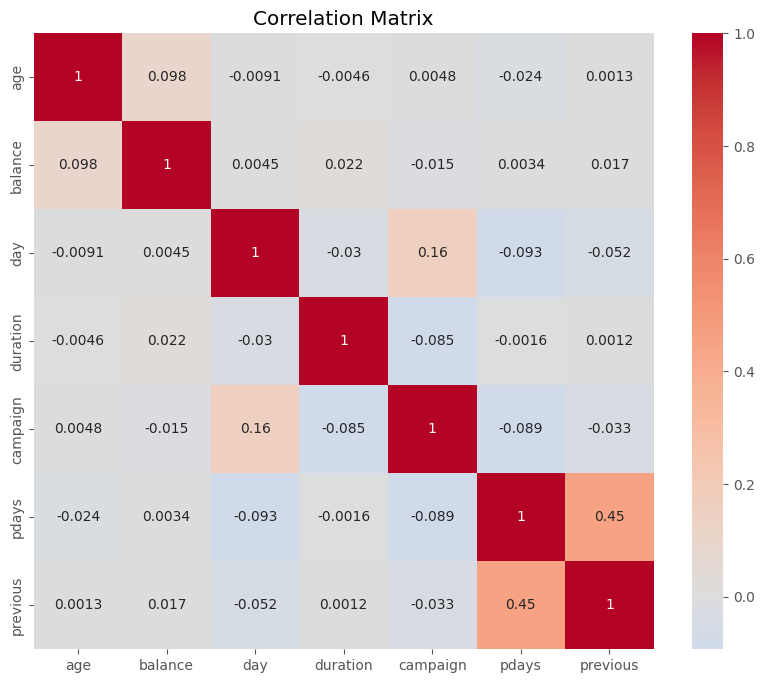

In [6]:
# Correlation analysis
correlation = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


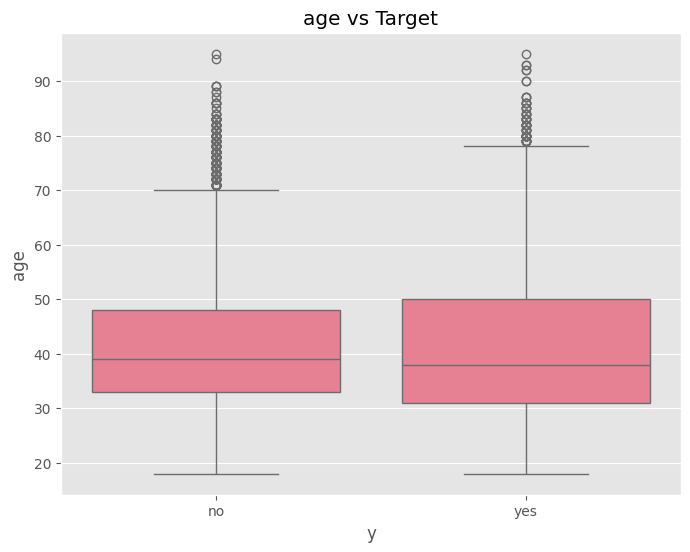

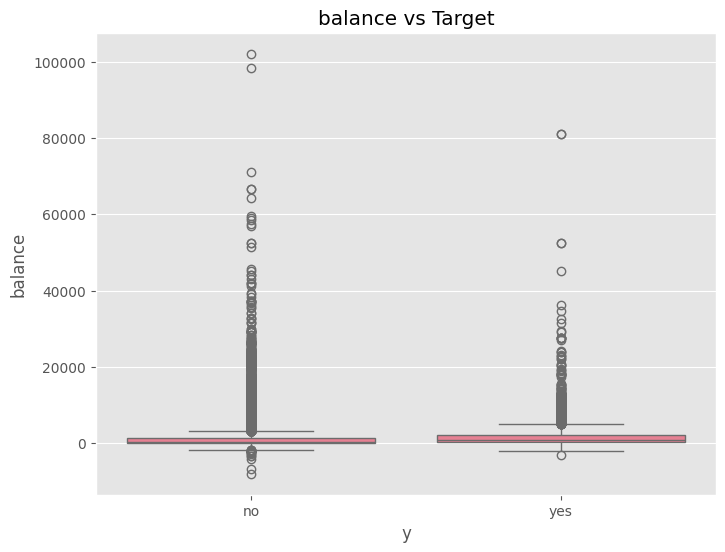

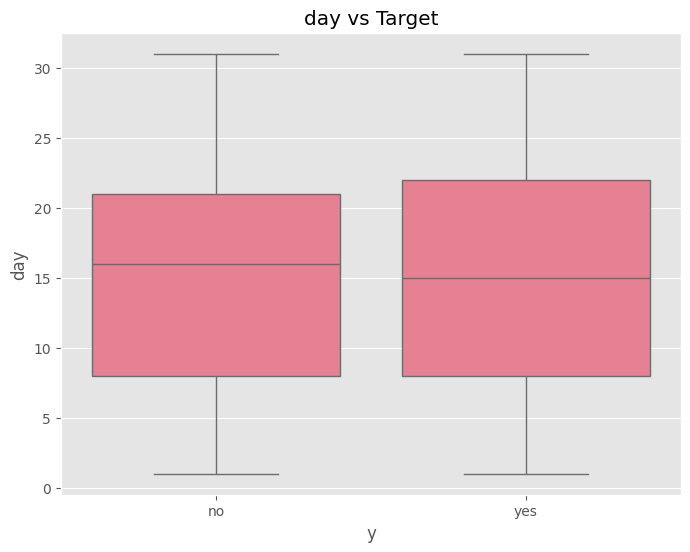

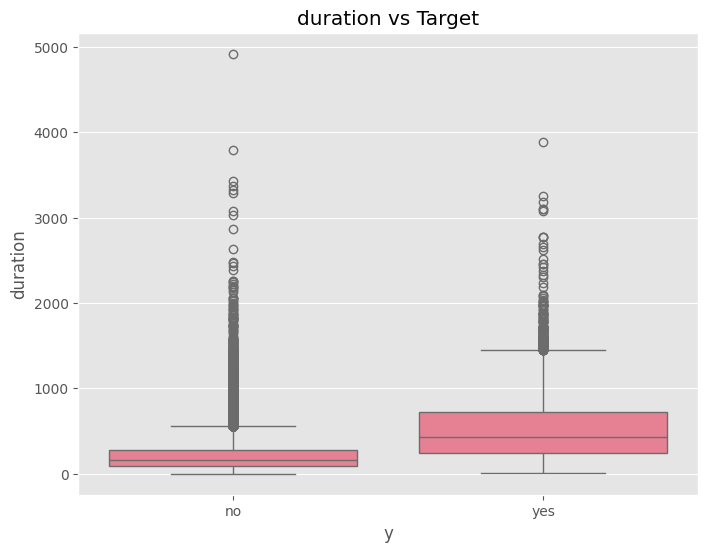

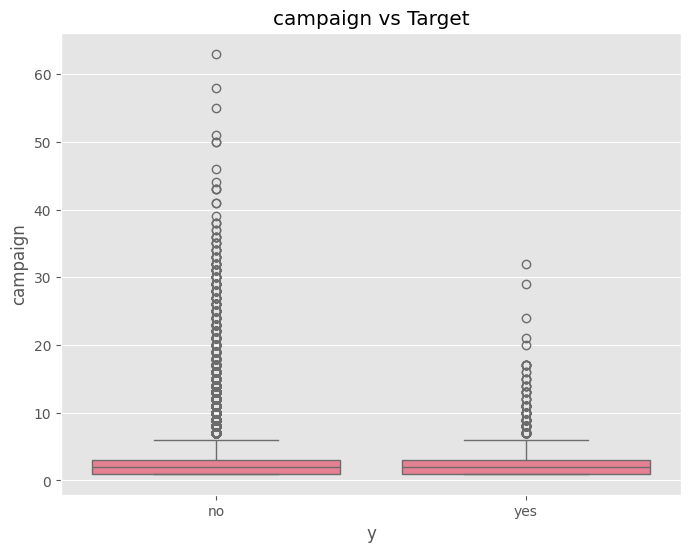

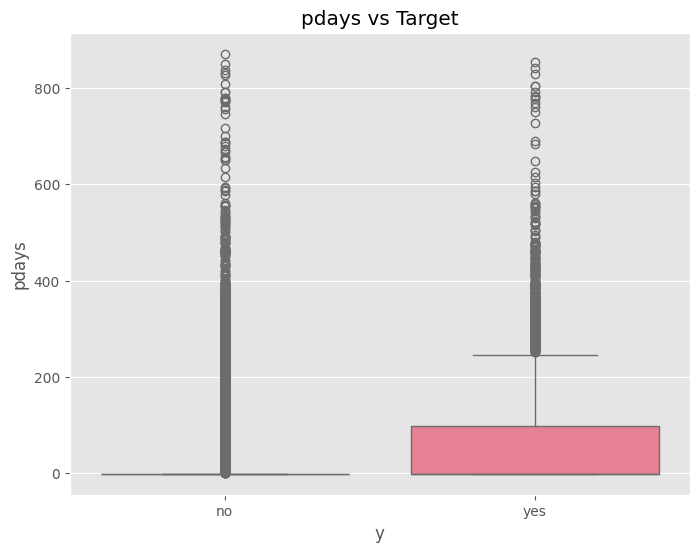

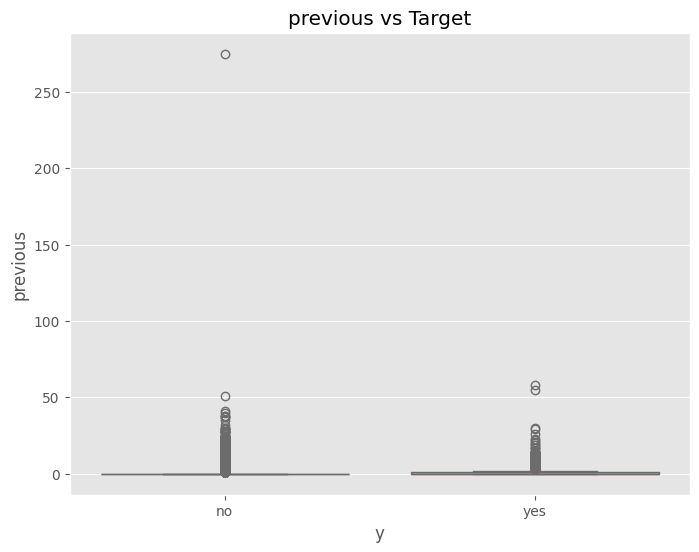

In [7]:
# Feature relationships with target
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='y', y=feature, data=df)
    plt.title(f'{feature} vs Target')
    plt.show()


Target Variable Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage Distribution:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


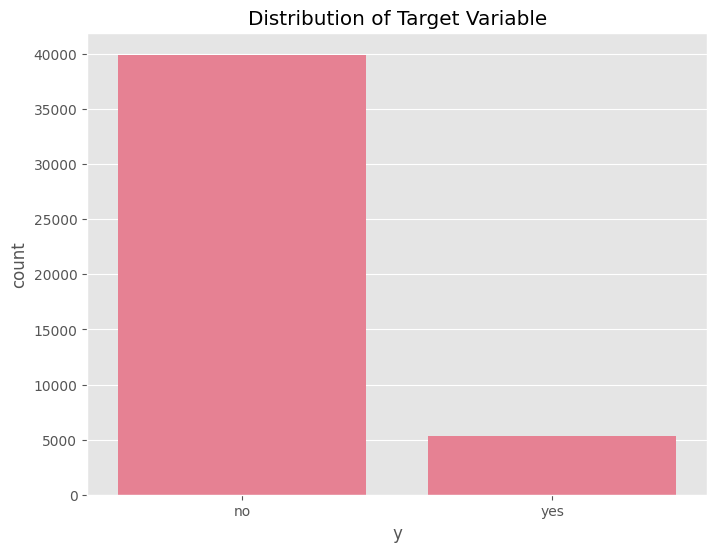

In [8]:
# Analyze target variable distribution
print("Target Variable Distribution:")
print(df['y'].value_counts())
print("\nPercentage Distribution:")
print(df['y'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='y')
plt.title('Distribution of Target Variable')
plt.show()